In [1]:
import os
import sys
import torch
import numpy as np
import scipy.io
import h5py
import argparse
from random import SystemRandom

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.distributions.normal import Normal
from torch.distributions import kl_divergence

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from lib.utils2D import *
from lib.functions2D import DeepONet1, GRU_unit, Decoder
from lib.ProposeModel2D import *
from lib.BaselineModel2D import *
from torch.multiprocessing import Pool

matplotlib.font_manager.fontManager.addfont('lib/fonts/times.ttf')

# set random seed
seed_value = 0
np.random.seed(seed_value)
random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value) 
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False 


In [2]:
experimentID = 800
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("experiments/experiment_" + str(experimentID) + '.ckpt')
args = checkpoint['args']

# read dataset
def read_data():
    reader = MatReader("data/dataset/data_" + args.data_version + ".mat")
    Xs = reader.read_field('Xs')
    ts = reader.read_field('ts').repeat(Xs.shape[0],1)
    xs = reader.read_field('xs')[0]
    ys = reader.read_field('ys')[0]
    try:
        us = reader.read_field('us')
    except:
        us = torch.zeros((Xs.shape[0],Xs.shape[2],Xs.shape[3])) 
        
    if args.data_version == 'nsV3':
        rs = ['_2','_3']
        for i in range(len(rs)):
            reader = MatReader("data/dataset/data_" + args.data_version + rs[i] + ".mat")
            Xs = torch.cat((Xs,reader.read_field('Xs')), axis=0)
            ts = torch.cat((ts,reader.read_field('ts').repeat(Xs.shape[0],1)), axis=0)
            try:
                us = torch.cat((us, reader.read_field('us')), axis=0)
            except:
                us = torch.cat((us, torch.zeros((Xs.shape[0],Xs.shape[2],Xs.shape[3]))), axis=0) 
    noise = (torch.tensor(np.random.sample(Xs.shape)).float() - 0.5) * 2.0
    #noise = torch.tensor(np.random.randn(Xs.shape)).float()
    Xs_noise = Xs + args.noise_weight * noise
    
    n = 5000
    T = 100
    s_GT = Xs[:n,:T]
    s = Xs_noise[:n,:T]
    us = us[:n]
    ts = ts[:n,:T]
    
    observed_points = int(T*args.obs_ratio)
    s_mask = torch.zeros(n, observed_points, len(xs), len(ys))
    t_mask = torch.zeros(n, observed_points)
    s_GT_mask = torch.zeros(n, observed_points, len(xs), len(ys))
    mask = np.zeros((n, T), dtype=int)
    for i in range(n):
        observed_indices = np.random.choice(np.arange(1,T), observed_points-1, replace=False)
        sorted_indices = np.sort(observed_indices)
        mask[i, 0] = 1
        mask[i, observed_indices] = 1
        s_mask[i,0] = s[i,0]
        s_mask[i,1:] = s[i,sorted_indices]
        s_GT_mask[i,0] = s_GT[i,0]
        s_GT_mask[i,1:] = s_GT[i,sorted_indices]
        t_mask[i,0] = ts[i,0]
        t_mask[i,1:] = ts[i,sorted_indices]
    mask = torch.tensor(mask)    

    Ntr = int(n * 0.99)
    
    s_data_tr = s_mask[:Ntr]; t_data_tr = t_mask[:Ntr]; u_data_tr = us[:Ntr] 
    s_data_te = s_mask[Ntr:]; t_data_te = t_mask[Ntr:]; u_data_te = us[Ntr:] 
    test_GT_mask = s_GT_mask[Ntr:]; test_GT = s_GT[Ntr:]; test_noise = s[Ntr:]

    print("s.shape:", s.shape)
    print("s_data_tr.shape:", s_data_tr.shape)
    print("t_data_tr.shape:", t_data_tr.shape)
    print("u_data_tr.shape:", u_data_tr.shape)
    print("Ntr:", Ntr)
    
    return(Ntr, s_data_te, t_data_te, u_data_te, xs, ts, mask, test_GT_mask, test_GT, test_noise) 
    
Ntr, s_data_te, t_data_te, u_data_te, xs, ts, mask, test_GT_mask, test_GT, test_noise = read_data()
args.input_dim = len(xs)

test_dataset_mask = [s_data_te.to(device), t_data_te.to(device), u_data_te.to(device)]
test_dataset = [test_noise.to(device), ts[Ntr:].to(device), u_data_te.to(device)]


s.shape: torch.Size([5000, 100, 32, 32])
s_data_tr.shape: torch.Size([4950, 60, 32, 32])
t_data_tr.shape: torch.Size([4950, 60])
u_data_tr.shape: torch.Size([4950, 32, 32])
Ntr: 4950


###############################################
800error: tensor(0.00317623)
error_mask: tensor(0.00319849)
error: tensor(0.00317623) +- tensor(0.00317497)


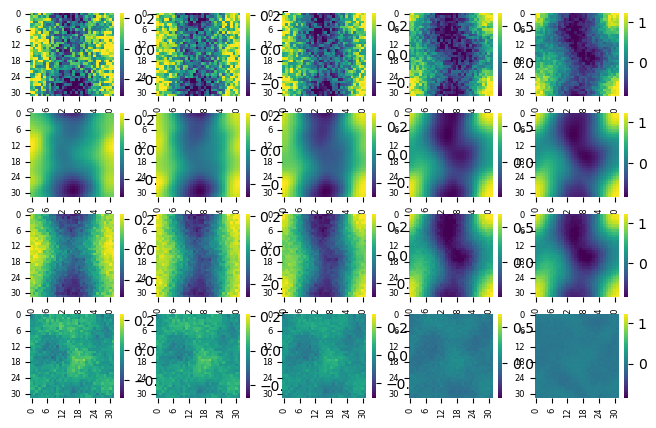

In [3]:
#expIDs = [800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811]
expIDs = [800]

for ei in range(len(expIDs)):
    experimentID = expIDs[ei]
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load("experiments/experiment_" + str(experimentID) + '.ckpt')
    args = checkpoint['args']
    
    if experimentID == 800:
        model = RLNO(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 801:
        model = DeepONet(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 802:
        model = GRUVAE(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 803:
        model = GRUDecay(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 804:
        model = MLAE_LD(args, device)
        model.load_state_dict(checkpoint['state_dict'])   
    elif experimentID == 805:
        model = LNODE(args, device)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 806:
        model = Base_PDENET(args, device, xs)
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 807:
        model = RLNO_MI(args, device, u_data_te.shape[-1])
        model.load_state_dict(checkpoint['state_dict'])
    elif experimentID == 808:
        model = MIONet(args, device, u_data_te.shape[-1])
        model.load_state_dict(checkpoint['state_dict'])      
    elif experimentID == 809:
        model = LNO_Ab1(args, device)
        model.load_state_dict(checkpoint['state_dict'])     
    elif experimentID == 810:
        model = LNO_Ab2(args, device)
        model.load_state_dict(checkpoint['state_dict']) 
    elif experimentID == 811:
        model = LNO_Ab3(args, device)
        model.load_state_dict(checkpoint['state_dict']) 
        
    ## testing
    batch_mask = test_dataset_mask
    batch = test_dataset
    pred_y = model.test(batch).cpu()
    pred_y_mask = model.test(batch_mask).cpu()
    
    index = 0
    s = batch[0][index].cpu()
    s_GT = test_GT[index].cpu()
    #s_mask = s * mask[index].unsqueeze(-1).repeat(1,len(xs)).t()
    print("###############################################")
    torch.set_printoptions(precision=8)
    if len(pred_y.shape) == 4:
        error = torch.mean((torch.mean(pred_y,axis=0).reshape(test_GT.shape)-test_GT)**2, (1,2,3))
        print(str(experimentID) + "error:", torch.mean(error))
        #print("error_before:", torch.mean((torch.mean(pred_y,axis=0).reshape(test_GT.shape) - test_GT)[:args.rec_len]**2))
        #print("error_later:", torch.mean((torch.mean(pred_y,axis=0).reshape(test_GT.shape) - test_GT)[args.rec_len:]**2))
        print("error_mask:", torch.mean((torch.mean(pred_y_mask,axis=0).reshape(test_GT_mask.shape) - test_GT_mask)**2))
        sp = torch.mean(pred_y,axis=0).reshape(test_GT.shape)[index].cpu().detach().numpy()
    else:
        error = torch.mean((pred_y.reshape(test_GT.shape) - test_GT)**2, (1,2,3))
        print(str(experimentID) + "error:", torch.mean(error))
        #print("error_before:", torch.mean((pred_y.reshape(test_GT.shape) - test_GT)[:args.rec_len]**2))
        #print("error_later:", torch.mean((pred_y.reshape(test_GT.shape) - test_GT)[args.rec_len:]**2))
        print("error_mask:", torch.mean((pred_y_mask.reshape(test_GT_mask.shape) - test_GT_mask)**2))
        sp = pred_y.reshape(test_GT.shape)[index].cpu().detach().numpy()
    print("error:",torch.mean(error), "+-", torch.std(error)*2)

    #fig = plt.figure(figsize=(3,3))
    
    fig = plt.figure(figsize=(16,5))
    num = 10; l = 10
    ma = 0.5; mi = -0.5
    ls = [0, 10, 20, 50, 99]
    lsn = 6
    for i in range(len(ls)):   
        ax = fig.add_subplot(4,num,i+1)
        data = pd.DataFrame(s[ls[i],:,:])
        data.replace(0, np.nan, inplace=True)
        s_max = s_GT[ls[i]].max(); s_min = s_GT[ls[i]].min()
        cmap = sns.heatmap(data, cmap='viridis', vmax=s_max, vmin=s_min)  #center=s.mean()
        plt.tick_params(labelsize=lsn)

        ax = fig.add_subplot(4,num,num+i+1)
        data = pd.DataFrame(s_GT[ls[i],:,:])
        data.replace(0, np.nan, inplace=True)
        s_max = s_GT[ls[i]].max(); s_min = s_GT[ls[i]].min()
        cmap = sns.heatmap(data, cmap='viridis', vmax=s_max, vmin=s_min)  
        plt.tick_params(labelsize=lsn)

        ax = fig.add_subplot(4,num,2*num+i+1)
        data = pd.DataFrame(sp[ls[i],:,:])
        data.replace(0, np.nan, inplace=True)
        s_max = s_GT[ls[i]].max(); s_min = s_GT[ls[i]].min()
        cmap = sns.heatmap(data, cmap='viridis', vmax=s_max, vmin=s_min) 
        plt.tick_params(labelsize=lsn)

        ax = fig.add_subplot(4,num,3*num+i+1)
        data = pd.DataFrame((s_GT - sp)[ls[i],:,:])
        data.replace(0, np.nan, inplace=True)
        s_max = s_GT[ls[i]].max(); s_min = s_GT[ls[i]].min()
        cmap = sns.heatmap(data, cmap='viridis', vmax=s_max, vmin=s_min) 
        plt.tick_params(labelsize=lsn)
    
    plt.savefig("results/{}.pdf".format(experimentID))   
    

In [4]:
reader = MatReader("data/dataset/data_nsV3.mat")
Xs = reader.read_field('Xs')
print(Xs.shape)

noise = (torch.tensor(np.random.sample(Xs.shape)).float() - 0.5) * 2.0
Xs_noise = Xs + 0.2 * noise


torch.Size([1000, 100, 64, 64])


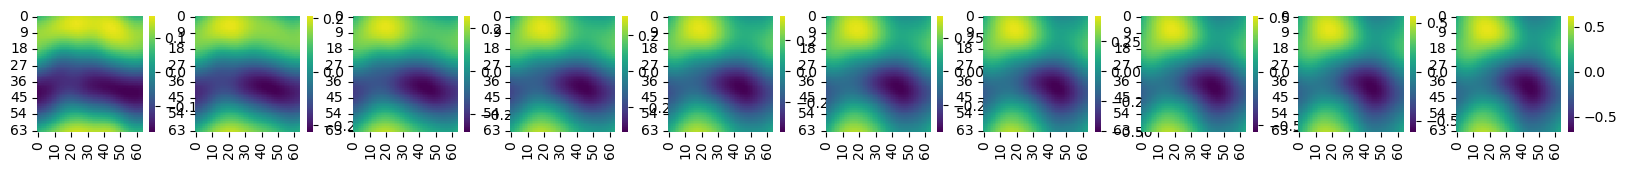

In [5]:
ind = 2
fig = plt.figure(figsize=(20,1.5))
num = 10
for i in range(num):
    s = Xs[ind,i*10,:,:]
    ax0 = fig.add_subplot(1,num,i+1)
    data = pd.DataFrame(s)
    data.replace(0, np.nan, inplace=True)
    #cmap = sns.heatmap(data, center=s.mean())
    cmap = sns.heatmap(data, cmap='viridis', center=s.mean())
    #plt.imshow(data, interpolation='nearest')


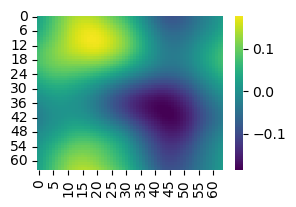

In [6]:
us = reader.read_field('us')

fig = plt.figure(figsize=(3,2))
u = us[ind]
data = pd.DataFrame(u)
data.replace(0, np.nan, inplace=True)
cmap = sns.heatmap(data, cmap='viridis', center=u.mean())


In [7]:
val1 = test_GT
val2 = pred_y[0].reshape(50,100,32,32)
ind = 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(20, 40))

ax1 = fig.add_subplot(211)
data = pd.DataFrame(val1[ind,0,:,:])
data.replace(0, np.nan, inplace=True)
cmap = sns.heatmap(data, cmap='viridis', center=val1[ind].mean(), cbar=False)

ax2 = fig.add_subplot(212)
data = pd.DataFrame(val2[ind,0,:,:])
data.replace(0, np.nan, inplace=True)
cmap = sns.heatmap(data, cmap='viridis', center=val2[ind].mean(), cbar=False)

def update(frame):
    """Update function for each animation frame"""
    # Clear the axis
    ax1.clear()
    ax2.clear()
    
    # Get the data for this frame
    s = val1[ind,frame,:,:]
    data = pd.DataFrame(s)
    data.replace(0, np.nan, inplace=True)
    sns.heatmap(data, cmap='viridis', center=val1[ind].mean(), ax=ax1, cbar=False)
    ax1.set_title(f'Time Step: {frame}')
    
    s = val2[ind,frame,:,:]
    data = pd.DataFrame(s)
    data.replace(0, np.nan, inplace=True)
    sns.heatmap(data, cmap='viridis', center=val2[ind].mean(), ax=ax2, cbar=False)
    ax2.set_title(f'Time Step: {frame}')
    
    # Remove axis labels for cleaner animation
    ax1.set_xticks([]); ax1.set_yticks([])
    ax2.set_xticks([]); ax2.set_yticks([])

# Create animation
ani = FuncAnimation(fig, update, frames=100, interval=200)
ani.save('animation.gif', writer='pillow', fps=5)
plt.close()  # Prevents duplicate display in notebooks
